In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import glob
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None
# https://stackoverflow.com/questions/20625582/how-to-deal-with-settingwithcopywarning-in-pandas
from pathlib import Path
from tqdm import tqdm
import re

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# Samples vs Power (fixed dataset)
def samples_vs_power(df: pd.DataFrame, **filter):
    # apply filter
    assert 'dataset' in filter, 'Error: expected key <dataset> to be a filter.'
    idx = df.index > -1
    for col, value in filter.items():
        if isinstance(value, str) and value[0]=='[' and value[-1]==']':
            idx = idx & df.get(col, None).str.contains(value[1:-1])
        else:
            idx = idx & (df.get(col, None)==value)
    df: pd.DataFrame = df[idx]
    if len(df) == 0: return list()

    stats = list()
    for n_samples in df['n_samples'].unique():
        avg_power = df[df['n_samples']==n_samples]['power'].mean()
        std = df[df['n_samples']==n_samples]['power'].std()/2
        stats.append((n_samples, avg_power, std))
    return sorted(stats, key=lambda x: x[0])    # return sorted by n_samples

In [3]:
# Dimension vs Power (fixed N)
def dim_vs_power(df: pd.DataFrame, **filter):
    # apply filter
    assert 'n_samples' in filter, 'Error: expected key <n_samples> to be a filter.'
    idx = df.index > -1
    for col, value in filter.items():
        if isinstance(value, str) and value[0]=='[' and value[-1]==']':
            idx = idx & df.get(col, None).str.contains(value[1:-1])
        else:
            idx = idx & (df.get(col, None)==value)
    df: pd.DataFrame = df[idx]
    if len(df) == 0: return list()

    stats = list()
    for dataset in df['dataset'].unique():
        if re.search('HDGM', dataset):
            dim = int(dataset.split('-')[-1])
            avg_power = df[df['dataset']==dataset]['power'].mean()
            std = df[df['dataset']==dataset]['power'].std()/2
            stats.append((dim, avg_power, std))
        else:
            print(f"Warning: dim_vs_power only applies to HDGM.")
    return sorted(stats, key=lambda x: x[0])    # return sorted by dim

In [4]:
def collate_samples(stats: list):                       # [(x1,y1,std1), (x2,y2,std2), ...]
    x, y, std = (np.array(obj) for obj in zip(*stats))  # (x1,x2,...), (y1,y2,...), (std1,std2,...)
    return {
        'x,y': (x, y),
        'std': (x, np.clip(y-std,0,1), np.clip(y+std,0,1)),
    }
    return x, y, y-std, y+std

(-0.05500000000000001,
 0.05500000000000001,
 -0.05500000000000001,
 0.05500000000000001)

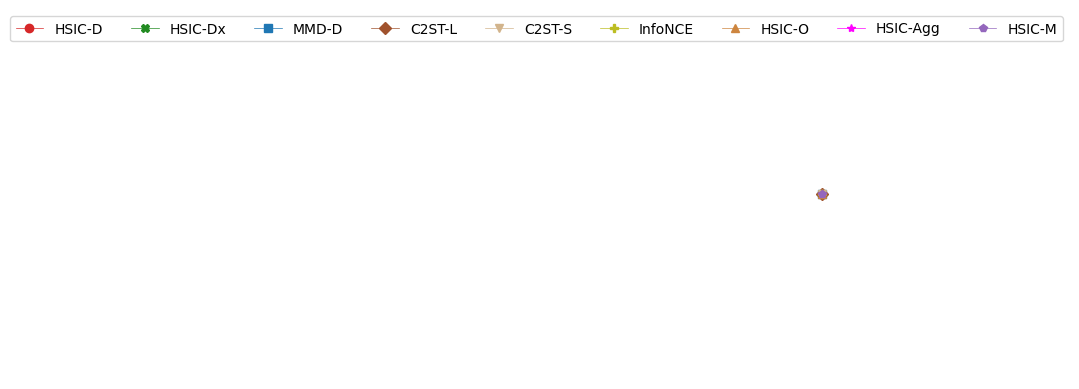

In [5]:
# LOAD DATAFRAME
EXPDIR = '../src/exp/eval/hdgm/'
RUNS = ('19', '20', '21') #('13','14','15')

df = dict()
for method in ['hsic', 'c2st', 'mmd', 'infonce']:
    runs = []
    for file in glob.glob(f'{EXPDIR}/*/stats-{method}.csv'):
        if Path(file).parent.name in RUNS:
            runs.append(pd.read_csv(file))
    df[method] = pd.concat(runs, axis=0) if runs else pd.DataFrame()


# DEFINE LEGEND
legend = dict()
legend['hsic-d'] = {'label': 'HSIC-D', 'marker': 'o-', 'color': 'tab:red'}
legend['hsic-dx'] = {'label': 'HSIC-Dx', 'marker': 'X-', 'color': 'forestgreen'}
legend['hsic-o'] = {'label': 'HSIC-O', 'marker': '^-', 'color': 'peru'}
legend['hsic-agg'] = {'label': 'HSIC-Agg', 'marker': '*-', 'color': 'magenta'}
legend['hsic-m'] = {'label': 'HSIC-M', 'marker': 'p-', 'color': 'tab:purple'}
legend['c2st-l'] = {'label': 'C2ST-L', 'marker': 'D-', 'color': 'sienna'}
legend['c2st-s'] = {'label': 'C2ST-S', 'marker': 'v-', 'color': 'tan'}
legend['mmd-d'] = {'label': 'MMD-D', 'marker': 's-', 'color': 'tab:blue'}
legend['infonce'] = {'label': 'InfoNCE', 'marker': 'P-', 'color': 'tab:olive'}
# ordered from least to most important
methods = ['hsic-m', 'hsic-agg', 'hsic-o', 'infonce', 'c2st-s', 'c2st-l', 'mmd-d', 'hsic-dx', 'hsic-d']

# Plot legend
for method in reversed(methods):
    plt.plot(0, 0, legend[method]['marker'], linewidth=0.5, color=legend[method]['color'])
plt.legend([legend[method]['label'] for method in reversed(methods)], ncol=len(methods))
plt.axis(False)
# plt.savefig(f"toyplots/legend.pdf", format="pdf", bbox_inches="tight")

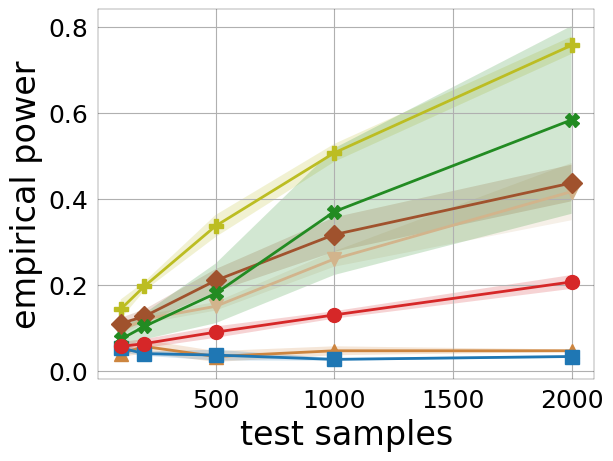

In [10]:
# power vs samples for fixed dimension
DATASET = 'HDGM-50'
LINEWIDTH = 2
MARKERSIZE = 10

stats = dict()
stats['hsic-d'] = samples_vs_power(df['hsic'], dataset=DATASET, method='hsic', model='[mlp.*squared]')
stats['hsic-dx'] = samples_vs_power(df['hsic'], dataset=DATASET, method='hsic', model='[tied]')
stats['hsic-agg'] = samples_vs_power(df['hsic'], dataset=DATASET, method='hsic', model='agg')
stats['hsic-o'] = samples_vs_power(df['hsic'], dataset=DATASET, method='hsic', model='bandwidth-squared')
stats['hsic-m'] = samples_vs_power(df['hsic'], dataset=DATASET, method='hsic', model='median')
stats['mmd-d'] = samples_vs_power(df['mmd'], dataset=DATASET, method='mmd')
stats['c2st-l'] = samples_vs_power(df['c2st'], dataset=DATASET, method='c2st-l')
stats['c2st-s'] = samples_vs_power(df['c2st'], dataset=DATASET, method='c2st-s')
stats['infonce'] = samples_vs_power(df['infonce'], dataset=DATASET, method='infonce')

for method in methods:
    try:
        plt.plot(*collate_samples(stats[method])['x,y'],
                legend[method]['marker'],
                linewidth = LINEWIDTH,
                markersize = MARKERSIZE,
                color = legend[method]['color'],)
        plt.fill_between(*collate_samples(stats[method])['std'],
                        facecolor = legend[method]['color'],
                        alpha = 0.2)
    except ValueError:
        print(f"Warning: no data found for method {method}.")


# plt.legend(['HSIC-D', 'HSIC-Dx', 'HSIC-Agg', 'HSIC-O', 'HSIC-M', 'MMD-D', 'C2ST-L', 'C2ST-S'], ncol=8)
plt.grid()
#plt.title(DATASET)
plt.xlabel("test samples", fontsize=24)
plt.ylabel("empirical power", fontsize=24)
#plt.xlim(xmin=90)

plt.rcParams['axes.linewidth'] = 0.2
plt.tick_params(left=False, labelsize=18)
plt.tick_params(bottom=False, labelsize=18)
# plt.gca().xaxis.set_major_locator(plt.MultipleLocator(1000))
# plt.savefig(f"plots/nsamples_vs_power_{DATASET.replace('-','')}.pdf", format="pdf", bbox_inches="tight")

In [ ]:
# power vs dimension for fixed number of samples
N_SAMPLES = 2000
LINEWIDTH = 2
MARKERSIZE = 10

stats = dict()
stats['hsic-d'] = dim_vs_power(df['hsic'], n_samples=N_SAMPLES, kernel='[mlp.*squared]')
stats['hsic-dx'] = dim_vs_power(df['hsic'], n_samples=N_SAMPLES, kernel='[tied]')
stats['hsic-agg'] = dim_vs_power(df['hsic'], n_samples=N_SAMPLES, kernel='hsic-agg')
stats['hsic-o'] = dim_vs_power(df['hsic'], n_samples=N_SAMPLES, kernel='bandwidth-squared')
stats['hsic-m'] = dim_vs_power(df['hsic'], n_samples=N_SAMPLES, kernel='median')
stats['mmd-d'] = dim_vs_power(df['mmd'], n_samples=N_SAMPLES)
stats['c2st-l'] = dim_vs_power(df['c2st'], n_samples=N_SAMPLES, type='logit')
stats['c2st-s'] = dim_vs_power(df['c2st'], n_samples=N_SAMPLES, type='accuracy')
stats['infonce'] = dim_vs_power(df['infonce'], n_samples=N_SAMPLES)

for method in methods:
    try:
        plt.plot(*collate_samples(stats[method])['x,y'],
                legend[method]['marker'],
                linewidth = LINEWIDTH,
                markersize = MARKERSIZE,
                color = legend[method]['color'],)
        plt.fill_between(*collate_samples(stats[method])['std'],
                        facecolor = legend[method]['color'],
                        alpha = 0.2)
    except ValueError:
        print(f"Warning: no data found for method {method}.")


plt.grid()
plt.ylim(0, 1.05)
plt.xlabel("dimension", fontsize=24)
plt.ylabel("empirical power", fontsize=24)
plt.rcParams['axes.linewidth'] = 0.2
plt.tick_params(left=False, labelsize=18)
plt.tick_params(bottom=False, labelsize=18)
# plt.savefig(f"plots/dim_vs_power_n{N_SAMPLES}.pdf", format="pdf", bbox_inches="tight")


In [ ]:
# J vs. HSIC
DATASET = 'HDGM-8'
LINEWIDTH = 2
MARKERSIZE = 10

legend = dict()
legend['J'] = {'label': 'hsic', 'marker': 'o-', 'color': 'tab:red'}
legend['hsic'] = {'label': 'J', 'marker': 'X-', 'color': 'steelblue'}

stats = dict()
stats['J'] = samples_vs_power(df['hsic'], dataset=DATASET, method='hsic', model='[mlp.*squared]')
stats['hsic'] = samples_vs_power(df['hsic'], dataset=DATASET, method='hsic-raw', model='[mlp.*squared]')

for method in ['hsic', 'J']:
    try:
        plt.plot(*collate_samples(stats[method])['x,y'],
                legend[method]['marker'],
                linewidth = LINEWIDTH,
                markersize = MARKERSIZE,
                color = legend[method]['color'],)
        plt.fill_between(*collate_samples(stats[method])['std'],
                        facecolor = legend[method]['color'],
                        alpha = 0.2)
    except ValueError:
        print(f"Warning: no data found for method {method}.")


obj_j = mpatches.Patch(color='tab:red', label='J')
obj_hsic = mpatches.Patch(color='steelblue', label='hsic')
plt.legend(handles=[obj_j, obj_hsic], prop={'size': 15})

# plt.legend(['J', None, 'J'])
plt.grid()
#plt.title(DATASET)
plt.xlabel("test samples", fontsize=24)
plt.ylabel("empirical power", fontsize=24)
#plt.xlim(xmin=90)

plt.rcParams['axes.linewidth'] = 0.2
plt.tick_params(left=False, labelsize=18)
plt.tick_params(bottom=False, labelsize=18)
# plt.gca().xaxis.set_major_locator(plt.MultipleLocator(1000))
plt.savefig(f"plots/J_vs_hsic_{DATASET.replace('-','')}.pdf", format="pdf", bbox_inches="tight")